# Diabetes Prediction Model
This project aims to develop a machine learning model that can predict the likelihood of an individual having diabetes based on various health parameters. The model will utilize a dataset containing features such as age, BMI, blood pressure, glucose levels, and other relevant health indicators.

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load the dataset
df = pd.read_csv('diabetes_prediction_dataset.csv')
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


## Data exploration

In [66]:
# shape of the dataset
print("Shape of the dataset:", df.shape)

# structure of the dataset
print("Structure of the dataset:")
print(df.info())

Shape of the dataset: (100000, 9)
Structure of the dataset:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB
None


## Data Cleaning and Preprocessing
* Identify and remove duplicate records.
* Handle missing or anomalous values.
* Encode categorical features (e.g., gender, smoking_history) into numerical formats.

In [67]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# This dataset typically contains a tiny fraction of 'Other' in gender. Dropping them keeps it binary.
df = df[df['gender'] != 'Other']

# Convert text to numbers
# drop_first=True prevents the dummy variable trap (redundant columns)
df = pd.get_dummies(df, columns=['gender', 'smoking_history'], drop_first=True)

# Convert age to type int. If there are any non-numeric values, they will be converted to NaN.
df['age'] = df['age'].astype(int)

# Verify the new structure
print(df.shape)
df.head()

(96128, 13)


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Male,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80,0,1,25.19,6.6,140,0,False,False,False,False,True,False
1,54,0,0,27.32,6.6,80,0,False,False,False,False,False,False
2,28,0,0,27.32,5.7,158,0,True,False,False,False,True,False
3,36,0,0,23.45,5.0,155,0,False,True,False,False,False,False
4,76,1,1,20.14,4.8,155,0,True,True,False,False,False,False


## Exploratory Data Analysis (EDA) and Visualizations

* Assess class balance of the target variable.
* Visualize continuous variables (age, BMI, HbA1c_level, blood_glucose_level) using histograms and boxplots.
* Plot a correlation matrix to identify relationships among features.


Target Variable Distribution (Percentage):
diabetes
0    91.176348
1     8.823652
Name: proportion, dtype: float64


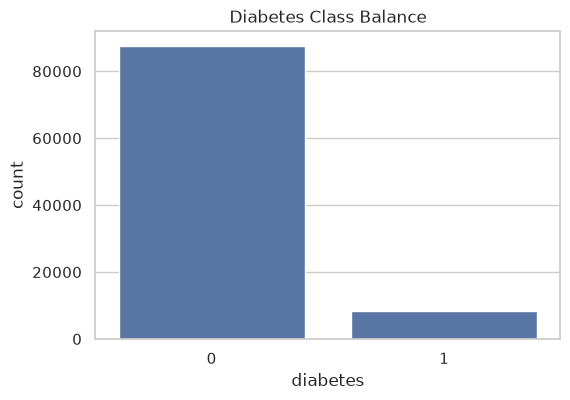

In [68]:
# Set visual style
sns.set_theme(style="whitegrid")

# Assess class balance
print("Target Variable Distribution (Percentage):")
print(df['diabetes'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='diabetes')
plt.title('Diabetes Class Balance')

# Save the figure
plt.savefig('visualizations/diabetes_class_balance.png', bbox_inches='tight')
plt.show()

This indicates that the dataset has massive class imbalance, with a significantly higher number of non-diabetic cases compared to diabetic cases. This imbalance can lead to biased model predictions, favoring the majority class. To address this issue, we will consider techniques such as oversampling the minority class, undersampling the majority class, or using advanced methods like SMOTE (Synthetic Minority Over-sampling Technique) to create synthetic samples for the minority class.

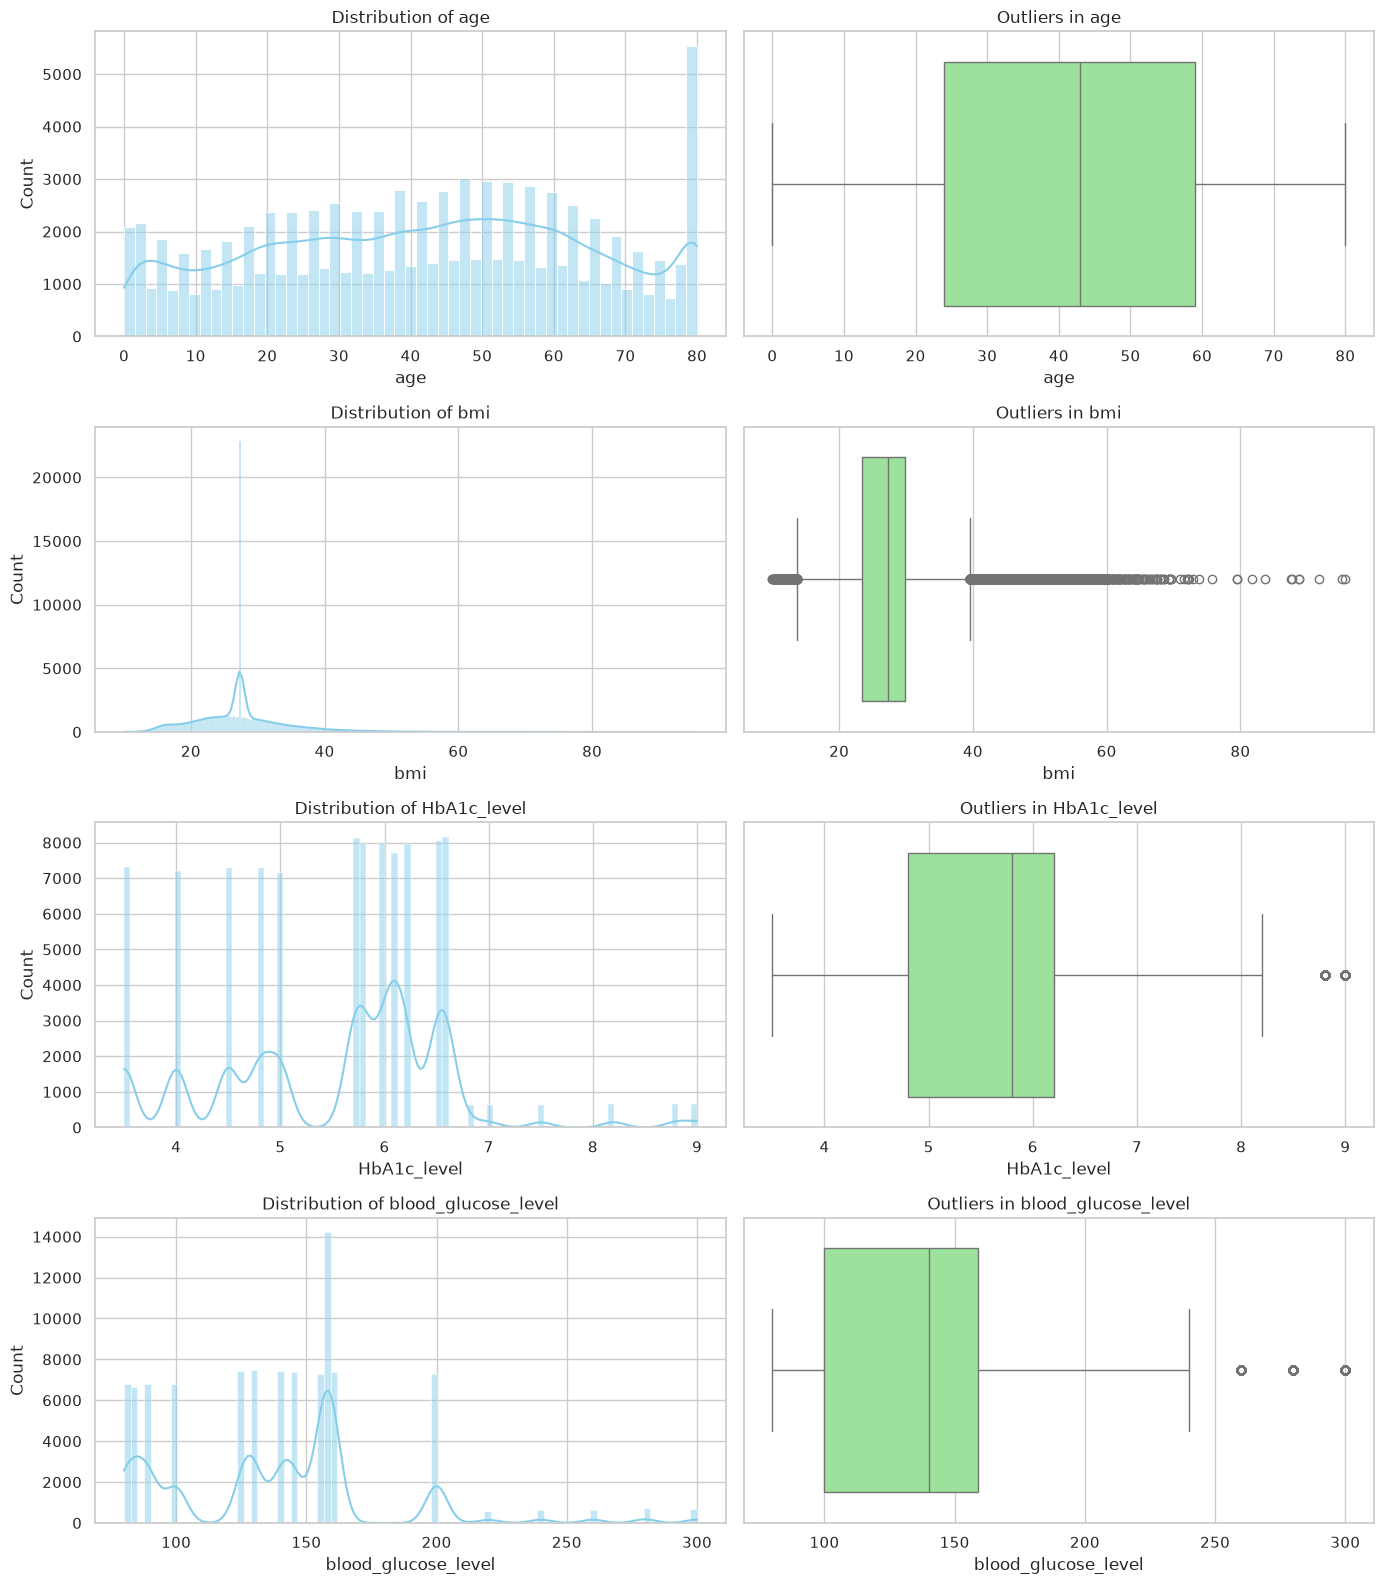

In [69]:
# Visualize continuous variables (Histograms and Boxplots)
continuous_vars = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

fig, axes = plt.subplots(len(continuous_vars), 2, figsize=(14, 16))
for i, var in enumerate(continuous_vars):
    # Histogram for data spread
    sns.histplot(df[var], kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Distribution of {var}')
    
    # Boxplot for outliers
    sns.boxplot(x=df[var], ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f'Outliers in {var}')

plt.tight_layout()

# Save the figures
plt.savefig('visualizations/continuous_variables.png', bbox_inches='tight')
plt.show()


* **Age:** The unnatural spike at 80 indicates the dataset caps age at 80. Anyone older is simply recorded as 80. The boxplot confirms there are no outliers.
* **BMI:** The massive, single spike around 27 is a clear anomaly. It strongly indicates that missing BMI values were artificially filled using the dataset's mean or median before you downloaded it. The boxplot shows a long right tail of extreme outliers reaching nearly 100.
* **HbA1c_level & blood_glucose_level:** The histograms feature sharp, separated vertical spikes rather than smooth continuous curves. This means the medical readings were recorded in discrete, rounded intervals. Both features display significant high-value outliers in their boxplots, which represent extreme medical readings likely tied to the diabetic patients.

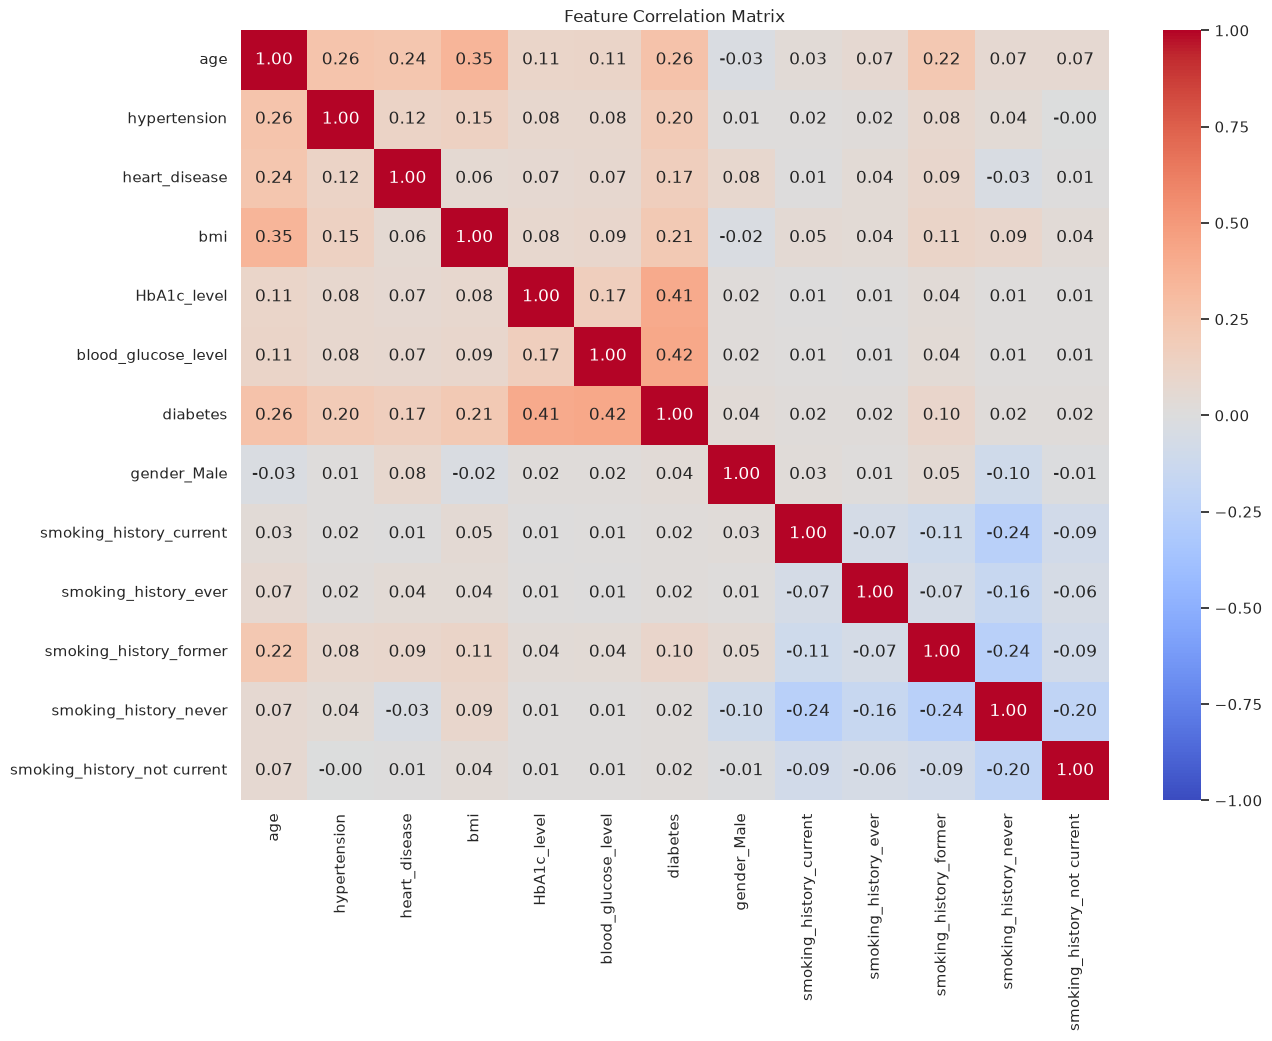

In [70]:
# Correlation Matrix
plt.figure(figsize=(14, 10))
# Convert boolean columns to float for accurate correlation calculation
corr_matrix = df.astype(float).corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix')

# Save the figure
plt.savefig('visualizations/correlation_matrix.png', bbox_inches='tight')
plt.show()

- Primary Indicators: As expected medically, blood sugar metrics will heavily drive your model's predictions.

- Secondary Indicators: Age (0.26) and BMI (0.21) offer moderate predictive value.

- Weak Features: Gender and smoking history categories have near-zero correlation (0.02 to 0.10) with diabetes. They will add very little value to your model.

- No Multicollinearity: The independent variables are not highly correlated with each other (the highest relationship is between age and BMI at 0.35). No need to remove any features due to multicollinearity.

## Statistical Tests
* Run Chi-square tests for categorical features to assess their association with diabetes.


In [71]:
from scipy.stats import chi2_contingency

# List of all binary/categorical features from your cleaned dataset
categorical_features = [
    'hypertension', 'heart_disease', 'gender_Male', 
    'smoking_history_current', 'smoking_history_ever', 
    'smoking_history_former', 'smoking_history_never', 
    'smoking_history_not current'
]

print("Chi-Square Test Results (Alpha = 0.05):\n")

for feature in categorical_features:
    # Create a frequency table comparing the feature against the target
    contingency_table = pd.crosstab(df[feature], df['diabetes'])
    
    # Run the test
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    
    # Interpret the p-value
    status = "Significant impact" if p < 0.05 else "No significant impact"
    
    print(f"{feature}:")
    print(f"  p-value: {p:.4e} -> {status}\n")

Chi-Square Test Results (Alpha = 0.05):

hypertension:
  p-value: 0.0000e+00 -> Significant impact

heart_disease:
  p-value: 0.0000e+00 -> Significant impact

gender_Male:
  p-value: 1.0113e-31 -> Significant impact

smoking_history_current:
  p-value: 1.4629e-07 -> Significant impact

smoking_history_ever:
  p-value: 1.3038e-11 -> Significant impact

smoking_history_former:
  p-value: 2.5390e-192 -> Significant impact

smoking_history_never:
  p-value: 8.3852e-13 -> Significant impact

smoking_history_not current:
  p-value: 4.2379e-09 -> Significant impact



All the features in the dataset are statistically significant, with p-values less than 0.05. This indicates that there is a significant association between each feature and the target variable (diabetes). Therefore, all features can be considered for model training.

## Feature Engineering
* Create new features based on existing ones (e.g., BMI categories, age groups).
* Normalize or standardize continuous features to improve model performance.
* Scale numerical features to a similar range to ensure fair contribution to the model.

In [72]:
from sklearn.preprocessing import StandardScaler

# Create BMI Categories
# Based on standard medical thresholds
bmi_bins = [0, 18.5, 24.9, 29.9, 100]
bmi_labels = ['Underweight', 'Normal', 'Overweight', 'Obese']
df['bmi_category'] = pd.cut(df['bmi'], bins=bmi_bins, labels=bmi_labels)

# Create Age Groups
age_bins = [0, 12, 19, 59, 150]
age_labels = ['Child', 'Teen', 'Adult', 'Senior']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)

# One-hot encode the new categorical features to convert them into numbers
df = pd.get_dummies(df, columns=['bmi_category', 'age_group'], drop_first=True)

Addressing data leakage correction:

Data leakage occurs when information from outside the training dataset is used to create the model, leading to overly optimistic performance estimates. To prevent data leakage, we will ensure that any feature engineering or scaling is performed only on the training data and then applied to the test data. This means that any transformations (like scaling or encoding) will be fitted on the training set and then used to transform both the training and test sets.

In [73]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df.drop('diabetes', axis=1)
y = df['diabetes']

# Split the data into training (80%) and testing (20%) sets
# stratify=y ensures the same ratio of diabetic patients in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize the scaler
scaler = StandardScaler()
continuous_vars = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

# Fit ON TRAINING DATA ONLY, then transform both
X_train[continuous_vars] = scaler.fit_transform(X_train[continuous_vars])
X_test[continuous_vars] = scaler.transform(X_test[continuous_vars])


Addressing the class imbalance:

We will address the class imbalance in the dataset using advanced techniques such as SMOTE (Synthetic Minority Over-sampling Technique) to create synthetic samples for the minority class. This will help balance the dataset and improve the model's ability to correctly predict diabetic cases.

In [74]:
# Install imbalanced-learn if you haven't already: pip install imbalanced-learn
from imblearn.over_sampling import SMOTE
import pandas as pd

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data ONLY
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Verify the new class balance
print("Original training target balance:")
print(y_train.value_counts())

print("\nResampled training target balance:")
print(y_train_resampled.value_counts())

Original training target balance:
diabetes
0    70116
1     6786
Name: count, dtype: int64

Resampled training target balance:
diabetes
0    70116
1    70116
Name: count, dtype: int64


## Predictive Analytics

In [75]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# Train and test each model
for name, model in models.items():
    # Train using the SMOTE-balanced data
    model.fit(X_train_resampled, y_train_resampled)
    
    # Make predictions on the strictly isolated test data
    y_pred = model.predict(X_test)
    
    # Display the results
    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred))
    print("\n")

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.99      0.88      0.93     17530
           1       0.42      0.88      0.57      1696

    accuracy                           0.88     19226
   macro avg       0.70      0.88      0.75     19226
weighted avg       0.94      0.88      0.90     19226



--- Decision Tree ---
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     17530
           1       0.68      0.74      0.71      1696

    accuracy                           0.95     19226
   macro avg       0.83      0.85      0.84     19226
weighted avg       0.95      0.95      0.95     19226



--- Random Forest ---
              precision    recall  f1-score   support

           0       0.98      0.97      0.98     17530
           1       0.74      0.76      0.75      1696

    accuracy                           0.96     19226
   macro avg       0.86      0.87      0.86     1922


- Logistic Regression: Fails. It catches 88% of diabetics (recall), but its precision is 42%. More than half the people it flags as diabetic are actually healthy (massive false positives).

- Decision Tree: Precision improves to 68%, but it misses 26% of actual diabetics (recall 0.74).

- Random Forest: The strongest baseline. It balances the trade-off, achieving 74% precision and 76% recall with an F1-score of 0.75 for the diabetic class.

In [76]:
import xgboost as xgb
from sklearn.metrics import classification_report

# Initialize XGBoost classifier
xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')

# Train using the SMOTE-balanced data
xgb_model.fit(X_train_resampled, y_train_resampled)

# Make predictions on the strictly isolated test data
y_pred_xgb = xgb_model.predict(X_test)

# Display the results
print("--- XGBoost ---")
print(classification_report(y_test, y_pred_xgb))

--- XGBoost ---
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     17530
           1       0.92      0.71      0.80      1696

    accuracy                           0.97     19226
   macro avg       0.95      0.85      0.89     19226
weighted avg       0.97      0.97      0.97     19226



XGBoost traded recall for massive precision. It is 92% correct when it flags a patient as diabetic, but it now misses 29% of actual cases (recall 0.71).

Since the F1-score is higher in XGBoost (0.80) than Random Forest (0.75), it is the better model for this dataset

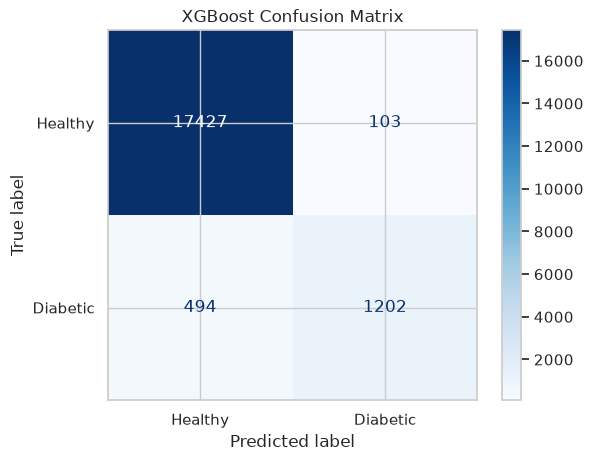

In [77]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy', 'Diabetic'])
disp.plot(cmap='Blues')
plt.title('XGBoost Confusion Matrix')


# Save the figure
plt.savefig('visualizations/xgboost_confusion_matrix.png', bbox_inches='tight')
plt.show()



The model correctly identified 17,427 healthy patients and 1,202 diabetic patients.

    - True Negatives (17,427): Healthy patients correctly predicted as healthy.
    - True Positives (1,202): Diabetic patients correctly predicted as diabetic.
    - False Negatives (494): Diabetic patients incorrectly predicted as healthy. This is a critical failure in a medical context because 494 sick patients will go undiagnosed and untreated.
    - False Positives (103): Healthy patients incorrectly flagged as diabetic

Due to the high number of false negatives, we will adjust the classification threshold to improve recall. By lowering the threshold from 0.5 to 0.3, we aim to catch more diabetic cases, even if it means accepting a higher number of false positives.

--- XGBoost (Threshold: 0.3) ---
              precision    recall  f1-score   support

           0       0.98      0.97      0.97     17530
           1       0.73      0.78      0.75      1696

    accuracy                           0.95     19226
   macro avg       0.85      0.87      0.86     19226
weighted avg       0.96      0.95      0.96     19226



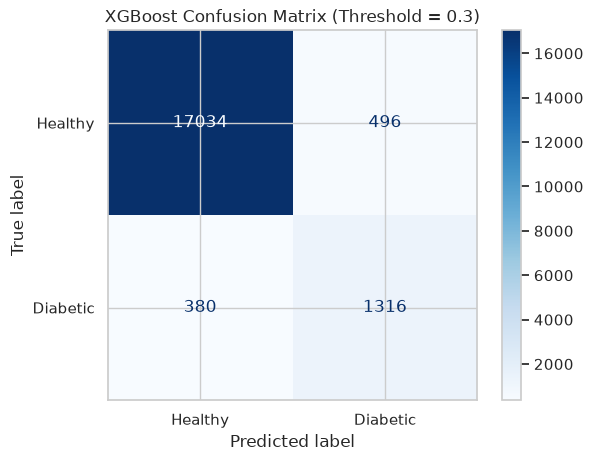

In [78]:
# Extract raw prediction probabilities for the positive class (Diabetic)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Define the new lower threshold
custom_threshold = 0.3

# Apply the threshold: If probability >= 0.3, classify as 1 (Diabetic), else 0
y_pred_adjusted = (y_prob_xgb >= custom_threshold).astype(int)

# Evaluate the new predictions
print("--- XGBoost (Threshold: 0.3) ---")
print(classification_report(y_test, y_pred_adjusted))

# Visualize the adjusted confusion matrix
cm_adjusted = confusion_matrix(y_test, y_pred_adjusted)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_adjusted, display_labels=['Healthy', 'Diabetic'])
disp.plot(cmap='Blues')
plt.title('XGBoost Confusion Matrix (Threshold = 0.3)')

plt.savefig('visualizations/xgboost_confusion_matrix_threshold_0.3.png', bbox_inches='tight')
plt.show()


- False Negatives (Missed Cases): Dropped from 494 to 380. You successfully caught 114 more diabetic patients who would have otherwise been missed.
- False Positives (False Alarms): Increased from 103 to 496. 393 more healthy patients are now incorrectly flagged as diabetic.

Using Adjusted Class Weights: XGBoost has a scale_pos_weight parameter. Setting this tells the algorithm to heavily penalize mathematical errors made against the diabetic class during training.
- Adjusted Class Weights does not work with SMOTE. It is designed to work with imbalanced datasets, not oversampled datasets. Therefore, we will train the model on the original imbalanced dataset and use the scale_pos_weight parameter to adjust for class imbalance.


--- XGBoost (Class Weights) ---
              precision    recall  f1-score   support

           0       0.99      0.92      0.95     17530
           1       0.50      0.88      0.64      1696

    accuracy                           0.91     19226
   macro avg       0.75      0.90      0.80     19226
weighted avg       0.94      0.91      0.92     19226



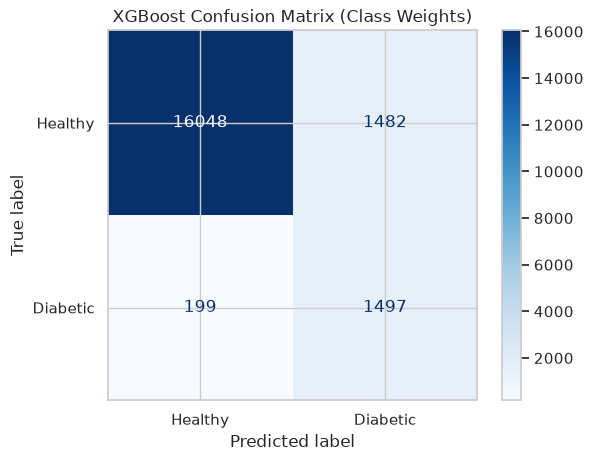

In [79]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate the weight ratio from the original imbalanced training data
weight_ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

# Initialize new model with scale_pos_weight
xgb_weighted = xgb.XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=weight_ratio)

# Train on the ORIGINAL X_train and y_train
xgb_weighted.fit(X_train, y_train)

# Predict and evaluate on the test set
y_pred_weighted = xgb_weighted.predict(X_test)

print("--- XGBoost (Class Weights) ---")
print(classification_report(y_test, y_pred_weighted))

# Visualize the new confusion matrix
cm_weighted = confusion_matrix(y_test, y_pred_weighted)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_weighted, display_labels=['Healthy', 'Diabetic'])
disp.plot(cmap='Blues')
plt.title('XGBoost Confusion Matrix (Class Weights)')

plt.savefig('visualizations/xgboost_confusion_matrix_class_weights.png', bbox_inches='tight')
plt.show()

- False Negatives (Missed Cases): Dropped to 199. You are now correctly catching 88% of all actual diabetic patients (recall = 0.88).
- False Positives (False Alarms): Increased to 1,482. Your precision dropped to 50%, meaning half the people the model flags as diabetic are actually healthy.

In a clinical setting, this is exactly what you want from a first-line screening tool. It prioritizes high recall to ensure sick patients are caught. The financial and operational cost of running a secondary confirmation blood test on 1,482 healthy people is negligible compared to the medical risk of leaving diabetic patients undiagnosed.

In [80]:
from sklearn.model_selection import cross_val_score
import joblib

# Run 5-fold cross-validation on the recall metric
scores = cross_val_score(xgb_weighted, X_train, y_train, cv=5, scoring='recall')
print("Cross-Validation Recall Scores:", scores)
print("Average Recall:", scores.mean())


Cross-Validation Recall Scores: [0.87988209 0.87997054 0.86956522 0.86809138 0.89093589]
Average Recall: 0.877689024238037


Model Saving and Deployment: The final model will be saved using joblib for deployment in a clinical setting. This allows healthcare providers to use the model for real-time diabetes prediction based on patient data.

In [81]:
# Save the final model for deployment
joblib.dump(xgb_weighted, 'xgboost_diabetes_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']